원본 데이터 크기: (94355, 43)
[1단계] 탈주자 제거 후 크기: (94322, 42) (제거된 게임 수: 33)
[2단계] 격차(Diff) 변수 생성 완료: (94322, 21)
[3단계] 이상치(IQR) 제거 후 최종 데이터 크기: (93716, 21)
--------------------------------------------------

[분석 결과] 주요 변수 통계 분석 (Top 5):
                 Feature     Win_Mean    Lose_Mean    Diff_Mean  Correlation  \
13        TotalGold_Diff  2520.559297 -2540.666282  5061.225579     0.600194   
14  TotalExperience_Diff  1589.414362 -1765.696646  3355.111008     0.576102   
5             Kills_Diff     3.869884    -3.611597     7.481481     0.552754   
6            Deaths_Diff    -3.869884     3.611597    -7.481481    -0.552754   
7           Assists_Diff     4.356932    -4.568496     8.925428     0.458533   

    P-Value  
13      0.0  
14      0.0  
5       0.0  
6       0.0  
7       0.0  


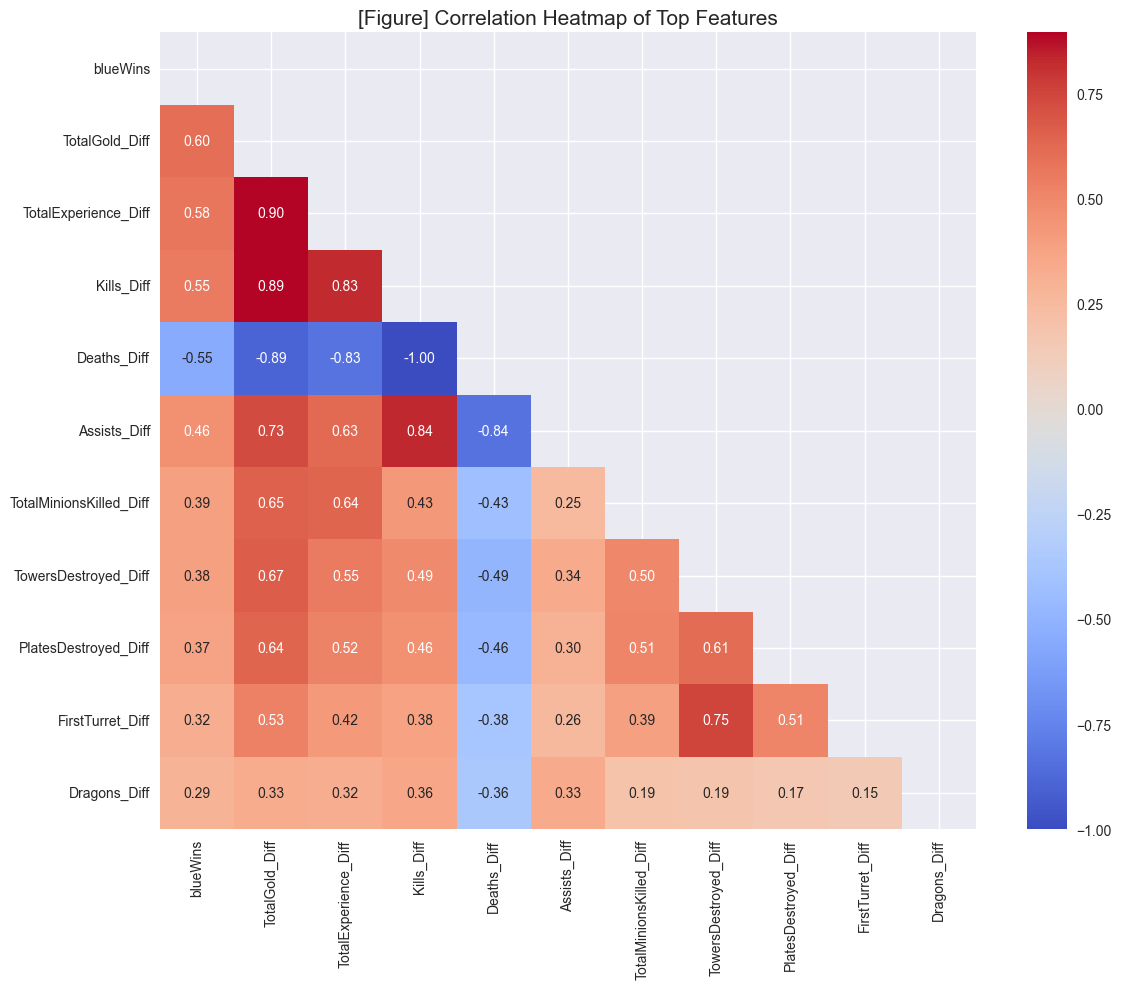


[모델 학습 중...]
586/586 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step

[최종 분석 결과] 모델별 성능 비교:
            Model  Accuracy  Precision  Recall (Win)  F1-Score  \
0  Logistic (PCA)  0.779236   0.772929      0.740869  0.756560   
1         XGBoost  0.781477   0.778264      0.738449  0.757834   
2             DNN  0.779449   0.812543      0.680724  0.740815   

   Recall (Defeat)  
0         0.812320  
1         0.818579  
2         0.864580  


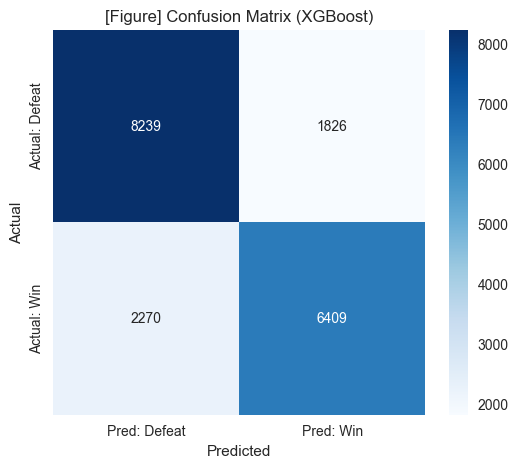

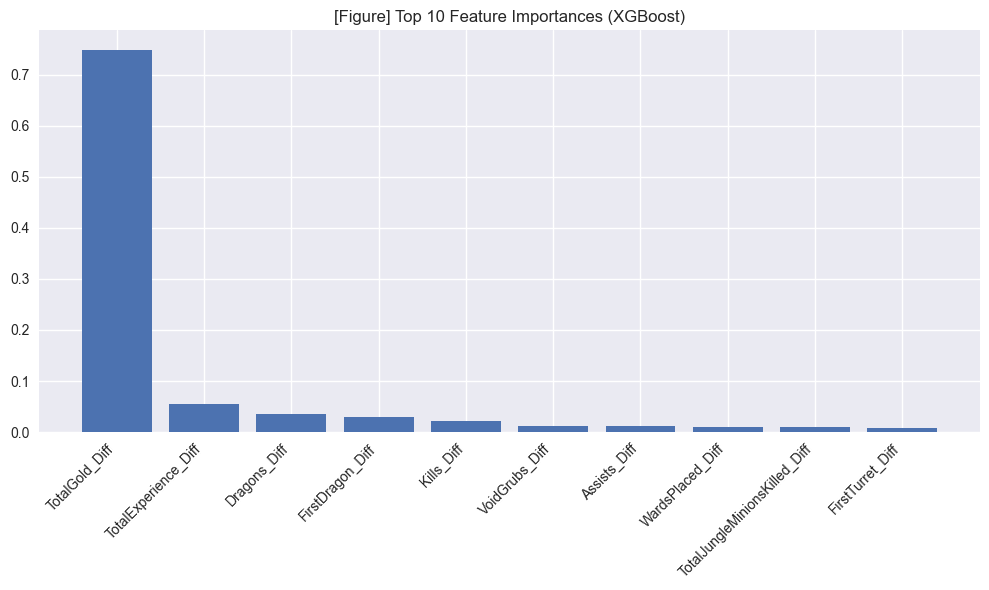

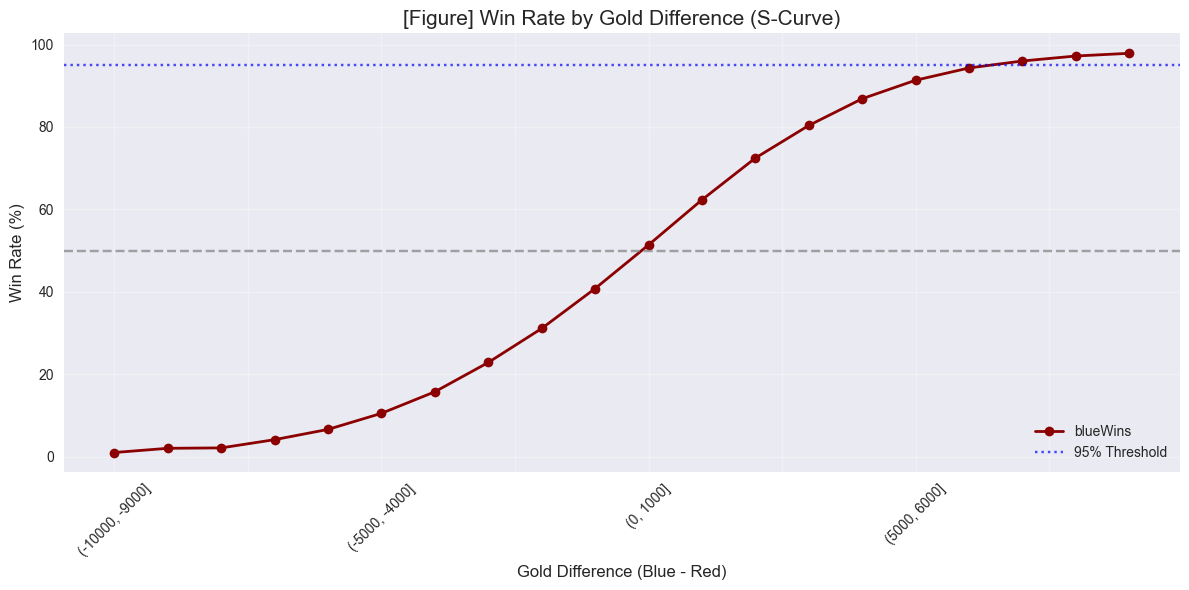


[Insight] 골드 격차에 따른 승률 분석:
Gold_Bin
(-10000, -9000]     1.006289
(-9000, -8000]      2.027027
(-8000, -7000]      2.125604
(-7000, -6000]      4.123366
(-6000, -5000]      6.614323
(-5000, -4000]     10.511159
(-4000, -3000]     15.741994
(-3000, -2000]     22.851871
(-2000, -1000]     31.102598
(-1000, 0]         40.792763
(0, 1000]          51.373757
(1000, 2000]       62.316107
(2000, 3000]       72.454508
(3000, 4000]       80.366448
(4000, 5000]       86.852917
(5000, 6000]       91.340320
(6000, 7000]       94.316029
(7000, 8000]       96.012759
(8000, 9000]       97.219809
(9000, 10000]      97.877984
Name: blueWins, dtype: float64


In [ ]:
# =============================================================================
# 0. 라이브러리 임포트 및 환경 설정
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import networkx as nx

# 머신러닝
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 모델
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 시각화 설정 (한글 폰트가 필요하면 주석 해제 후 설정)
plt.style.use('seaborn-v0_8-whitegrid')
# plt.rc('font', family='Malgun Gothic') 
# plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. 데이터 로드 및 전처리 (3단계 프로세스)
# =============================================================================
print(">>> 데이터 로드 및 전처리 시작...")
df = pd.read_csv('final.csv')

# 1.1 [1단계] 탈주자(AFK) 제거 (20,000 골드 미만)
# 정상적인 15분 게임의 이론적 하한선 적용
df_clean = df[
    (df['blueTotalGold'] > 20000) & 
    (df['redTotalGold'] > 20000)
].copy()

# 1.2 [2단계] 변수 재설계 (Diff 변환)
# 대칭 변수(Blue/Red)를 '격차(Diff)' 변수로 통합
blue_cols = [col for col in df_clean.columns if col.startswith('blue') and col != 'blueWins']
diff_data = pd.DataFrame()
diff_data['blueWins'] = df_clean['blueWins']

for b_col in blue_cols:
    r_col = b_col.replace('blue', 'red')
    if r_col in df_clean.columns:
        diff_col_name = b_col.replace('blue', '') + '_Diff'
        diff_data[diff_col_name] = df_clean[b_col] - df_clean[r_col]

# 1.3 [3단계] 고의 패배 및 이상치 제거 (IQR)
# 핵심 변수인 Gold_Diff를 기준으로 극단치 제거
Q1 = diff_data['TotalGold_Diff'].quantile(0.25)
Q3 = diff_data['TotalGold_Diff'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_final = diff_data[
    (diff_data['TotalGold_Diff'] >= lower_bound) & 
    (diff_data['TotalGold_Diff'] <= upper_bound)
].copy()

print(f"최종 데이터 크기: {df_final.shape}")

# =============================================================================
# 2. 통계적 분석 및 시각화
# =============================================================================
print("\n>>> 통계 분석 및 시각화 생성 중...")

# 2.1 주요 변수 T-test 및 Boxplot 시각화 (표 대체)
# 상관계수가 높은 상위 4개 변수 선정
correlations = df_final.corr()['blueWins'].abs().sort_values(ascending=False)
top_features = correlations.index[1:5].tolist()  # blueWins 제외 상위 4개

plt.figure(figsize=(12, 8))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='blueWins', y=feature, data=df_final, palette=['#ff9999', '#66b3ff'])
    plt.xticks([0, 1], ['Defeat', 'Victory'])
    plt.ylabel(feature)
    # T-test 검정 통계량 표시
    win = df_final[df_final['blueWins']==1][feature]
    lose = df_final[df_final['blueWins']==0][feature]
    t_stat, p_val = stats.ttest_ind(win, lose)
    plt.text(0.5, 0.9, f'p < {p_val:.2e}', ha='center', transform=plt.gca().transAxes, fontsize=10)

plt.tight_layout()
plt.show()

# 2.2 상관관계 히트맵 (상위 10개 변수)
top_10_cols = correlations.index[:11].tolist() # Target 포함
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df_final[top_10_cols].corr(), dtype=bool))
sns.heatmap(df_final[top_10_cols].corr(), annot=True, fmt=".2f", cmap='RdBu_r', mask=mask, vmin=-1, vmax=1)
plt.show()

# 2.3 그래피컬 모델 (Graphical Model - 인과관계 시각화)
def draw_graphical_model(df):
    G = nx.DiGraph()
    target = 'blueWins'
    
    # 주요 노드 정의 (계층 구조)
    # Layer 0: 원인 (킬, 타워, CS 등)
    # Layer 1: 결과 (골드, 경험치)
    # Layer 2: 최종 (승패)
    
    causes = ['Kills_Diff', 'TowersDestroyed_Diff', 'TotalMinionsKilled_Diff', 'Dragons_Diff']
    effects = ['TotalGold_Diff', 'TotalExperience_Diff']
    
    # 노드 추가
    G.add_node(target, layer=2)
    for node in effects: G.add_node(node, layer=1)
    for node in causes: G.add_node(node, layer=0)
    
    # 엣지 추가 (상관계수 0.3 이상일 때 연결)
    # 1. 원인 -> 결과
    for src in causes:
        for dst in effects:
            if src in df.columns and dst in df.columns:
                corr = df[[src, dst]].corr().iloc[0, 1]
                if abs(corr) > 0.3:
                    G.add_edge(src, dst, weight=abs(corr))
    
    # 2. 결과 -> 승패
    for src in effects:
        corr = df[[src, target]].corr().iloc[0, 1]
        G.add_edge(src, target, weight=abs(corr))

    # 그리기
    plt.figure(figsize=(12, 6))
    pos = nx.shell_layout(G)
    
    nx.draw_networkx_nodes(G, pos, node_color=['#ff9999' if n==target else '#99ff99' if n in effects else '#66b3ff' for n in G.nodes()], node_size=3000, alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
    
    edges = G.edges()
    weights = [G[u][v]['weight'] * 3 for u, v in edges]
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', arrowstyle='->', arrowsize=20)
    
    plt.axis('off')
    plt.show()

draw_graphical_model(df_final)

# =============================================================================
# 3. 머신러닝 모델링
# =============================================================================
print("\n>>> 머신러닝 모델 학습 및 검증 시작...")

X = df_final.drop('blueWins', axis=1)
y = df_final['blueWins']

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3.1 모델 파이프라인 정의
# (1) Logistic Regression & DNN용: Scaling + PCA
scaler = MinMaxScaler()
pca = PCA(n_components=0.95)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# (2) 모델 정의
models = {
    'Logistic (PCA)': LogisticRegression(penalty='l2', C=1.0, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric='logloss', random_state=42)
}

# 학습 및 평가 결과 저장
results = {}

# Scikit-learn / XGBoost 모델 학습
for name, model in models.items():
    if 'PCA' in name:
        model.fit(X_train_pca, y_train)
        preds = model.predict(X_test_pca)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall (Loss)': recall_score(y_test, preds, pos_label=0), # 패배 재현율 (중요)
        'F1-Score': f1_score(y_test, preds)
    }

# DNN 학습
dnn = Sequential([
    Dense(64, input_dim=X_train_pca.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
dnn.compile(loss='binary_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])
dnn.fit(X_train_pca, y_train, epochs=30, batch_size=64, verbose=0, validation_split=0.2, callbacks=[EarlyStopping(patience=3)])

dnn_preds_prob = dnn.predict(X_test_pca)
dnn_preds = (dnn_preds_prob > 0.5).astype(int).flatten()

results['DNN (PCA)'] = {
    'Accuracy': accuracy_score(y_test, dnn_preds),
    'Precision': precision_score(y_test, dnn_preds),
    'Recall (Loss)': recall_score(y_test, dnn_preds, pos_label=0),
    'F1-Score': f1_score(y_test, dnn_preds)
}

# =============================================================================
# 4. 결과 시각화 (표 대체)
# =============================================================================
print("\n>>> 최종 결과 시각화...")

# 4.1 모델 성능 비교 (막대 그래프)
metrics_df = pd.DataFrame(results).T
metrics_to_plot = ['Accuracy', 'F1-Score', 'Recall (Loss)']

metrics_df[metrics_to_plot].plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')
plt.ylim(0.7, 1.0) # 차이를 잘 보여주기 위해 y축 조정
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4.2 Confusion Matrix (Best Model: XGBoost 기준)
# 패배(0)를 얼마나 잘 맞췄는지 시각적으로 확인
best_model = models['XGBoost']
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred: Lose', 'Pred: Win'], 
            yticklabels=['Actual: Lose', 'Actual: Win'])
plt.show()

# 4.3 Feature Importance (XGBoost)
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Top 10

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[indices], align='center', color='#4c72b0')
plt.xticks(range(10), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4.4 [핵심 인사이트] 골드 격차별 승률 S-Curve
# 1000골드 단위 구간화
bins = list(range(-10000, 11000, 1000))
df_final['Gold_Bin'] = pd.cut(df_final['TotalGold_Diff'], bins=bins, labels=bins[:-1])

# 구간별 승률 계산
win_rate_df = df_final.groupby('Gold_Bin')['blueWins'].mean()
win_rate_df = win_rate_df.dropna()

plt.figure(figsize=(12, 6))
# 승률 곡선
plt.plot(win_rate_df.index.astype(int), win_rate_df.values * 100, marker='o', linewidth=2, color='#c44e52')

# 기준선 (50%, 95%)
plt.axhline(y=50, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=95, color='blue', linestyle=':', linewidth=2, label='Threshold (95%)')

# 항복 권고 구간 강조 (5000 골드 이상)
plt.axvspan(5000, 10000, color='red', alpha=0.1, label='Surrender Zone (>5k)')

plt.ylabel('Win Rate (%)')
plt.xlabel('Gold Difference')
plt.ylim(0, 105)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(">>> 모든 분석 및 시각화 완료.")